# Desafio Integracion
### Metodos Numericos

En este desafio, se debe calcular el periodo de un pendulo, comparando los resultados obtenidos por una formula simple encontrada en Fisica y los de una integral eliptica.<br>
La formula de fisica solo sirve para angulos mas pequeños, así que se haran dos experimentos: uno con ángulo pequeño, y uno con un ángulo mas grande.

La formula vista en fisica para determinar el periodo de oscilacion de un pendulo es:

$$ T \approx 2 \pi \sqrt{\frac{L}{g}}$$

Y la integral eliptica a usar seria:

$$T(\alpha_0) = 4 \sqrt{\frac{L}{g}} \int_{0}^{\frac{\pi}{2}} \frac{d\theta}{\sqrt{1-sen^2(\frac{\alpha_0}{2}) sen^2(\theta)}}$$

Nuestro primer angulo es de aproximadamente 14.12 grados. Lo aproximaremos a 15 grados, es decir, pi/12.

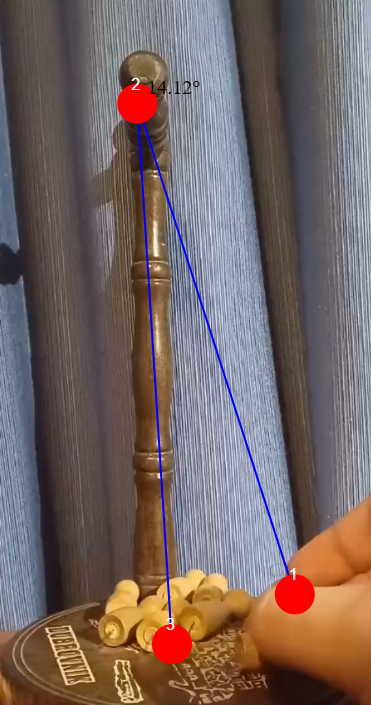

Nuestro segundo angulo es de aproximadamente 39.86 grados. Lo aproximaremos a 2pi/9.

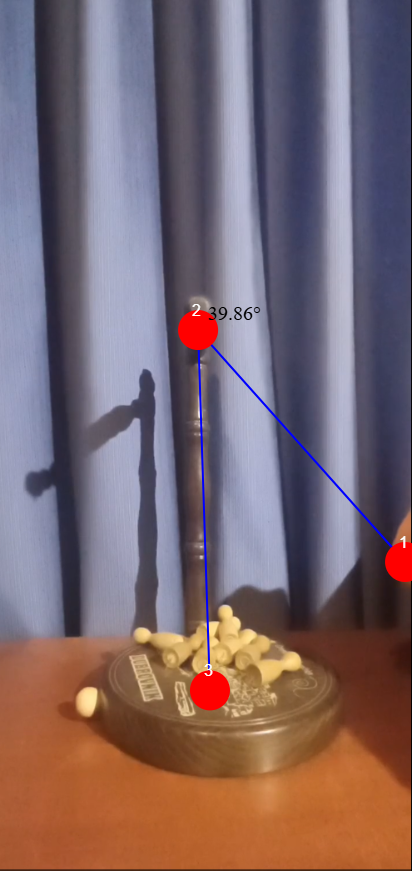

### 1. Importacion de librerias

In [161]:
import numpy as np
import sympy
import math
import matplotlib as plt

### 2. Calculos preliminares 

El hilo fue medido y llegue a que el largo es de 17cm.

In [162]:
L = 0.17 # 17cm = 0.17m
g = 9.81

periodo1simple = (2*math.pi)*np.sqrt((L/g))
print(f'Resultado del periodo usando formula de fisica: {periodo1simple} segundos')

Resultado del periodo usando formula de fisica: 0.8271224816602217 segundos


Recordar integral eliptica:

$$T(\alpha_0) = 4 \sqrt{\frac{L}{g}} \int_{0}^{\frac{\pi}{2}} \frac{d\theta}{\sqrt{1-sen^2(\frac{\alpha_0}{2}) sen^2(\theta)}}$$

In [163]:
# Integral eliptica:
alpha = 0
intEliptica = lambda x: 1 / np.sqrt(1 - (np.sin(alpha / 2)**2) * (np.sin(x)**2)) # funcion a usar para los proximos calculos

### 3. Calculos de integral del pendulo 1

Usaremos los metodos:
- Quad (Metodo general)
- Fixed-Quad (Gauss)
- Simpson
- Trapezoid (Trapecio)



In [164]:
# Redefinir variables para una mejor estructura
from math import pi
from scipy import integrate
import time
L = 0.17
g = 9.81
alpha = pi/12



print(f'=' * 30, '\nRESULTADOS METODO QUAD\n', '=' * 30)
inicio = time.time()
integral1quad, error = integrate.quad(intEliptica, 0, pi/2)
fin = time.time()
result1quad = 4 * np.sqrt(L / g) * integral1quad
print(f'Resultado: Periodo de {result1quad}s. Resultado alcanzado en {fin-inicio} segundos, con un error de {error}.')

RESULTADOS METODO QUAD
Resultado: Periodo de 0.8306795873787545s. Resultado alcanzado en 0.0 segundos, con un error de 1.7514341763154762e-14.


Para el metodo fixed-quad, usamos la misma metodolgia, pero usamos n puntos para la integral.

In [ ]:
print(f'=' * 30, '\nRESULTADOS METODO FIXED-QUAD\n', '=' * 30)
inicio = time.time()
integral1fixedquad, _ = integrate.fixed_quad(intEliptica, 0, pi/2, n=500)
fin = time.time()
result1fixedquad = 4 * np.sqrt(L / g) * integral1fixedquad
print(f'Resultado: Periodo de {result1fixedquad}s. Resultado alcanzado en {fin-inicio} segundos.')

Para usar el metodo de simpson, necesitamos un array de valores de theta y su valor al pasar por la funcion.

Este metodo tiene diferentes resultados basado en cuantos puntos tenemos en el espacio. Vamos a intentar varios casos:

In [ ]:
thetaVal = np.linspace(0, pi/2, 10)
yVal = 1 / np.sqrt(1 - (np.sin(alpha / 2)**2) * (np.sin(thetaVal)**2))


print(f'=' * 30, '\nRESULTADOS METODO SIMPSON, 10 PUNTOS\n', '=' * 30)
inicio2 = time.time()
integral1simpson = integrate.simpson(y=yVal, x=thetaVal)
fin2 = time.time()
result1simpson = 4 * np.sqrt(L / g) * integral1simpson
print(f'Resultado: Periodo de {result1simpson}s. Resultado alcanzado en {fin2-inicio2} segundos')

thetaVal2 = np.linspace(0, pi/2, 1000000)
yVal2 = 1 / np.sqrt(1 - (np.sin(alpha / 2)**2) * (np.sin(thetaVal2)**2))

print(f'=' * 30, '\nRESULTADOS METODO SIMPSON, 1000000 PUNTOS\n', '=' * 30)
inicio3 = time.time()
integral1simpson = integrate.simpson(y=yVal, x=thetaVal)
fin3 = time.time()
result1simpson = 4 * np.sqrt(L / g) * integral1simpson
print(f'Resultado: Periodo de {result1simpson}s. Resultado alcanzado en {fin3-inicio3} segundos')

RESULTADOS METODO SIMPSON, 10 PUNTOS
Resultado: Periodo de 0.8306793351839392s. Resultado alcanzado en 0.000997304916381836 segundos
RESULTADOS METODO SIMPSON, 1000000 PUNTOS
Resultado: Periodo de 0.8306793351839392s. Resultado alcanzado en 0.0 segundos


Para el metodo Trapezoid, debemos usar los mismos arreglos que usamos para Simpson.

In [ ]:
thetaVal = np.linspace(0, pi/2, 10)
yVal = 1 / np.sqrt(1 - (np.sin(alpha / 2)**2) * (np.sin(thetaVal)**2))


print(f'=' * 30, '\nRESULTADOS METODO TRAPEZOID, 10 PUNTOS\n', '=' * 30)
inicio2 = time.time()
integral1trapezoid = integrate.trapezoid(y=yVal, x=thetaVal)
fin2 = time.time()
result1trapezoid = 4 * np.sqrt(L / g) * integral1trapezoid
print(f'Resultado: Periodo de {result1trapezoid}s. Resultado alcanzado en {fin2-inicio2} segundos')

thetaVal2 = np.linspace(0, pi/2, 1000000)
yVal2 = 1 / np.sqrt(1 - (np.sin(alpha / 2)**2) * (np.sin(thetaVal2)**2))

print(f'=' * 30, '\nRESULTADOS METODO TRAPEZOID, 1000000 PUNTOS\n', '=' * 30)
inicio3 = time.time()
integral1trapezoid = integrate.trapezoid(y=yVal, x=thetaVal)
fin3 = time.time()
result1trapezoid = 4 * np.sqrt(L / g) * integral1trapezoid
print(f'Resultado: Periodo de {result1trapezoid}s. Resultado alcanzado en {fin3-inicio3} segundos')

RESULTADOS METODO TRAPEZOID, 10 PUNTOS
Resultado: Periodo de 0.8306795873787545s. Resultado alcanzado en 0.0 segundos
RESULTADOS METODO TRAPEZOID, 1000000 PUNTOS
Resultado: Periodo de 0.8306795873787545s. Resultado alcanzado en 0.0 segundos
